# Assignment 1
# Sparse Bayesian Neural Networks using Automatic Relevance Determination

Variational Dropout ([arXiv:1506.02557](https://arxiv.org/abs/1506.02557)) provides a Bayesian interpretation of the conventional dropout procedure. Later it was shown that Variational Dropout can be used for model sparsification (Sparse VD), an the effect can be achieved via optimization of variational lower bound wrt individual dropout rates for every weight of the model ([arXiv:1701.05369](https://arxiv.org/abs/1701.05369)).

In this assignment we would consider another interpretation of this model that uses the *Automatic Relevance Determination* (ARD) prior. This model is described in [arXiv:1811.00596](https://arxiv.org/abs/1811.00596).

#### ARD BNN

The ARD BNN model optimizes the evidence lower bound (ELBO) $\mathcal{L}(\phi)$ with respect to parameters $\phi$ of a variational approximation $q_\phi(w)$:

$$\mathcal{L}(\phi) =  L_\mathcal{D}(\phi) - D_{KL}(q_\phi(w)\,\|\,p(w\,|\,\lambda^2)) \to\max_{\phi, \lambda^2},$$
$$L_\mathcal{D}(\phi) = \sum_{n=1}^N \mathrm{E}_{q_\phi(w)}[\log p(y_n\,|\,x_n, w)],$$
$$p(w_{ij}\,|\,\lambda^2_{ij})=\mathcal{N}(w_{ij}\,|\,0,\lambda^2_{ij})\text{ is the ARD prior,}$$

$$q_\phi(w_{ij}) = \mathcal{N}(w_{ij}\,|\,\mu_{ij},\sigma^2_{ij})\text{ is the fully-factorized Gaussian posterior approximation},$$

and the log-likelihood $p(y\,|\,x, w)$ is defined by a neural network with parametrs $w$ using a conventional cross-entropy loss function. The optimization is performed by stochasic optimization methods. Adam with default hyperparameters and a simple multi step LR schedule should work fine.

The optimization w.r.t. the prior variance $\lambda^2$ can be performed analytically; the optimal value is $\lambda_{ij}^2=\mu_{ij}^2+\sigma_{ij}^2$. The KL-divergence term then becomes equal to:

$$D_{KL}(q_\phi(w)\,\|\,p(w\,|\,\lambda^2))=\frac12\sum_{ij}\log \left(1+\frac{\mu_{ij}^2}{\sigma_{ij}^2}\right).$$

**Note:** You will need to refer to the value $\log\alpha_{ij}=\log\frac{\sigma_{ij}^2}{\mu_{ij}^2}$ in order to determine which weights to zero out. It is also convenient to use it to compute the KL divergence. A rule of thumb is to zero out all the weights that have $\log\alpha_{ij}>3$, but you can use another threshold.

**Note:** Optimize w.r.t. $\log\sigma$ instead of $\sigma$ to better represent small values of $\sigma$.

**Note:** Some of the operations (e.g. log and square root) can be unstable for small arguments. In order to avoid NaNs, you can add a "safe" modification: just add a small constant (e.g. `1e-8`) to the argument and / or use appropriate clamping.

![alt text](https://raw.githubusercontent.com/senya-ashukha/senya-ashukha.github.io/bd8c169c6b162dac5aa77013d70463eae0927c5e/images/svd3.png)


# In this assignment:
1. Implementation of fully-connected ARD Layer
2. Training Lenet-300-100 on MNIST dataset (test accuracy should be $\geq 98.1$)
3. Optional Research Assignment

Additional information:
- If you have a problem with importing logger, download logger.py and file to the same folder and run a notebook from it
- You will need the following python packages: pytorch, numpy, sklearn, pylab (matplotlib), tabulate
- If you have an urgent question or find a typo or a mistake, text it to Alexander Grishin in Discord

In [1]:
from __future__ import annotations

import math
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.autograd import Variable
from torch.nn import Parameter
from torchvision import datasets, transforms
from typing import Tuple

## Logger

In [2]:
import os
import sys
import random
import numpy as np

from collections import OrderedDict
from tabulate import tabulate
from pandas import DataFrame
from time import gmtime, strftime


class Logger:
    def __init__(self, name='name', fmt=None):
        self.handler = True
        self.scalar_metrics = OrderedDict()
        self.fmt = fmt if fmt else dict()

        base = './logs'
        if not os.path.exists(base): os.mkdir(base)

        time = gmtime()
        hash = ''.join([chr(random.randint(97, 122)) for _ in range(3)])
        fname = '-'.join(sys.argv[0].split('/')[-3:])
        self.path = '%s/%s-%s-%s-%s' % (base, fname, name, hash, strftime('%m-%d-%H:%M', time))

        self.logs = self.path + '.csv'
        self.output = self.path + '.out'
        self.checkpoint = self.path + '.cpt'

        def prin(*args):
            str_to_write = ' '.join(map(str, args))
            with open(self.output, 'a') as f:
                f.write(str_to_write + '\n')
                f.flush()

            print(str_to_write)
            sys.stdout.flush()

        self.print = prin

    def add_scalar(self, t, key, value):
        if key not in self.scalar_metrics:
            self.scalar_metrics[key] = []
        self.scalar_metrics[key] += [(t, value)]

    def iter_info(self, order=None):
        names = list(self.scalar_metrics.keys())
        if order:
            names = order
        values = [self.scalar_metrics[name][-1][1] for name in names]
        t = int(np.max([self.scalar_metrics[name][-1][0] for name in names]))
        fmt = ['%s'] + [self.fmt[name] if name in self.fmt else '.1f' for name in names]

        if self.handler:
            self.handler = False
            self.print(tabulate([[t] + values], ['epoch'] + names, floatfmt=fmt))
        else:
            self.print(tabulate([[t] + values], ['epoch'] + names, tablefmt='plain', floatfmt=fmt).split('\n')[1])

    def save(self):
        result = None
        for key in self.scalar_metrics.keys():
            if result is None:
                result = DataFrame(self.scalar_metrics[key], columns=['t', key]).set_index('t')
            else:
                df = DataFrame(self.scalar_metrics[key], columns=['t', key]).set_index('t')
                result = result.join(df, how='outer')
        result.to_csv(self.logs)
        self.print('The log/output/model have been saved to: ' + self.path + ' + .csv/.out/.cpt')

## Implementation of  the Linear ARD layer

In [3]:
class LinearARD(nn.Module):
    def __init__(
        self, 
        in_features: int, 
        out_features: int, 
        threshold: float, 
        bias: bool = True
    ) -> None:
        super(LinearARD, self).__init__()
        """
            in_features: int, a number of input features
            out_features: int, a number of neurons
            threshold: float, a threshold for clipping weights
        """
        
        self.in_features = in_features
        self.out_features = out_features
        self.threshold = threshold

        self.mu = torch.nn.parameter.Parameter(
            data = torch.zeros((self.out_features, self.in_features))
        )
        self.log_sigma = torch.nn.parameter.Parameter(
            data = torch.zeros((self.out_features, self.in_features))
        )
        self.bias = torch.nn.parameter.Parameter(
            data = torch.zeros((1, self.out_features))
        )
        self.reset_parameters()
        
    def reset_parameters(self) -> None:
        self.bias.data.zero_()
        self.mu.data.normal_(0, 0.02)
        self.log_sigma.data.fill_(-5)        
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:      
        # x is a torch.Tensor of shape (number_of_objects, in_features)
        # log_alpha is a torch.Tensor of shape (out_features, in_features)
        self.log_alpha = 2 * self.log_sigma - torch.log(self.mu ** 2 + 1e-8) # Compute using self.log_sigma and self.mu
        # clipping for a numerical stability
        self.log_alpha = torch.clamp(self.log_alpha, -10, 10)   
        
        if self.training:
            lrt_mean = F.linear(x, weight=self.mu, bias=self.bias) # shape: (x.shape[0], out_features)
            lrt_std = torch.sqrt(
                F.linear(x ** 2, weight=torch.exp(2 * self.log_sigma)) + 1e-8
            ) # shape: (x.shape[0], out_features)
            eps = torch.randn((x.shape[0], self.out_features), device=self.mu.device)
            return lrt_mean + lrt_std * eps
        
        out = F.linear(x, weight=self.mu.masked_fill(self.log_alpha > 3, 0.0), bias=self.bias)
        return out
        
    def kl_reg(self) -> torch.Tensor:
        kl = torch.log(1 + torch.exp(-self.log_alpha)).sum() / 2
        return kl

## Define LeNet-300-100

In [4]:
class Net(nn.Module):
    def __init__(self, threshold: float) -> None:
        super(Net, self).__init__()
        self.fc1 = LinearARD(28*28, 300, threshold)
        self.fc2 = LinearARD(300,  100, threshold)
        self.fc3 = LinearARD(100,  10, threshold)
        self.threshold=threshold

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.log_softmax(self.fc3(x), dim=1)
        return x

## Function for loading MNIST

In [5]:
def get_mnist(batch_size: int) -> Tuple[DataLoader, DataLoader]:
    trsnform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_loader = DataLoader(
        datasets.MNIST('../data', train=True, download=True,
        transform=trsnform), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(
        datasets.MNIST('../data', train=False, download=True,
        transform=trsnform), batch_size=batch_size, shuffle=True)

    return train_loader, test_loader

## Define the ELBO loss function

In [6]:
class ELBO(nn.Module):
    def __init__(self, net: Net, train_size: int) -> None:
        super(ELBO, self).__init__()
        self.train_size = train_size # the len of dataset
        self.net = net
        
    def forward(
        self, 
        input: torch.Tensor, 
        target: torch.Tensor, 
        kl_weight: float = 1.0
    ) -> torch.Tensor:
        """
          input: is a torch.Tensor (a predictions of the model) 
          target: is a torch.Tensor (a tensor of labels) 
        """
        assert not target.requires_grad
        kl = 0.0
        for module in self.net.children():
            if hasattr(module, 'kl_reg'):
                kl = kl + module.kl_reg()
                
        elbo_loss = self.train_size * F.nll_loss(input, target) + kl_weight * kl
        return elbo_loss

## Define the model

In [7]:
model = Net(threshold=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[30, 60, 90],
    gamma=0.1,
)

logger = Logger('ard', fmt={
    'tr_loss': '3.1e',
    'te_loss': '3.1e',
    'sp_0':    '.3f',
    'sp_1':    '.3f',
    'sp_2':    '.3f',
    'lr':      '3.1e',
    'kl':      '.2f',
    'time':    '.2f',
})

train_loader, test_loader = get_mnist(batch_size=100)
elbo = ELBO(model, len(train_loader.dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.78MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.32MB/s]


## Train the model

In [8]:
# Switch the device to cuda to reduce one epoch from ~30 sec to ~10 sec

# device = 'cpu'
device = 'cuda:0'

model = model.to(device)
elbo = elbo.to(device)

kl_weight = 0.02
epochs = 200

for epoch in range(1, epochs + 1):
    time_start = time.perf_counter()
    scheduler.step()
    model.train()
    train_loss, train_acc = 0, 0 
    kl_weight = min(kl_weight+0.02, 1)
    logger.add_scalar(epoch, 'kl', kl_weight)
    logger.add_scalar(epoch, 'lr', scheduler.get_lr()[0])
    for batch_idx, (data, target) in enumerate(train_loader):
        data = data.to(device)
        target = target.to(device)
        
        data = data.view(-1, 28*28)
        optimizer.zero_grad()
        
        output = model(data)
        pred = output.data.max(1)[1] 
        loss = elbo(output, target, kl_weight)
        loss.backward()
        optimizer.step()
        
        train_loss += float(loss) 
        train_acc += np.sum(pred.cpu().numpy() == target.data.cpu().numpy())

    logger.add_scalar(epoch, 'tr_loss', train_loss / len(train_loader.dataset))
    logger.add_scalar(epoch, 'tr_acc', train_acc / len(train_loader.dataset) * 100)
    
    model.eval()
    test_loss, test_acc = 0, 0
    for batch_idx, (data, target) in enumerate(test_loader):
        data = data.to(device)
        target = target.to(device)
        
        data = data.view(-1, 28*28)
        output = model(data)
        test_loss += float(elbo(output, target, kl_weight))
        pred = output.data.max(1)[1] 
        test_acc += np.sum(pred.cpu().numpy() == target.data.cpu().numpy())
        
    logger.add_scalar(epoch, 'te_loss', test_loss / len(test_loader.dataset))
    logger.add_scalar(epoch, 'te_acc', test_acc / len(test_loader.dataset) * 100)
    
    for i, c in enumerate(model.children()):
        if hasattr(c, 'kl_reg'):
            logger.add_scalar(epoch, 'sp_%s' % i, (c.log_alpha.data.cpu().numpy() > model.threshold).mean())
    
    logger.add_scalar(epoch, 'time', time.perf_counter() - time_start)
    logger.iter_info()

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:578: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)
/tmp/ipykernel_55/1967292993.py:33: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  train_loss += float(loss)


  epoch    kl       lr    tr_loss    tr_acc    te_loss    te_acc    sp_0    sp_1    sp_2    time
-------  ----  -------  ---------  --------  ---------  --------  ------  ------  ------  ------
      1  0.04  1.0e-03    2.5e+02      91.1    1.3e+02      96.1   0.342   0.120   0.035   16.08
      2  0.06  1.0e-03    1.3e+02      96.5    1.1e+02      97.0   0.442   0.192   0.050   15.30
      3  0.08  1.0e-03    1.1e+02      97.3    9.7e+01      97.4   0.542   0.277   0.057   15.27
      4  0.10  1.0e-03    9.4e+01      97.8    9.9e+01      97.3   0.610   0.330   0.071   14.99
      5  0.12  1.0e-03    8.8e+01      98.0    8.9e+01      97.7   0.639   0.390   0.063   15.06
      6  0.14  1.0e-03    8.1e+01      98.3    8.7e+01      97.8   0.702   0.441   0.088   15.21
      7  0.16  1.0e-03    7.9e+01      98.3    8.0e+01      98.3   0.749   0.470   0.087   15.33
      8  0.18  1.0e-03    7.7e+01      98.4    8.3e+01      98.0   0.766   0.492   0.077   15.00
      9  0.20  1.0e-03    7.5e

In [9]:
all_w, kep_w = 0, 0

for c in model.children():
    kep_w += (c.log_alpha.data.cpu().numpy() < model.threshold).sum()
    all_w += c.log_alpha.data.cpu().numpy().size

# compression_ratio should be > 25
compression_ratio = all_w/kep_w
print('compression_ratio =', compression_ratio)
assert compression_ratio >= 25

compression_ratio = 25.117946782411774


## Disk space

In [10]:
import scipy
import numpy as np
from scipy.sparse import csc_matrix, csc_matrix, coo_matrix, dok_matrix

row, col, data = [], [], []
M = list(model.children())[0].mu.data.cpu().numpy()
LA = list(model.children())[0].log_alpha.data.cpu().numpy()

for i in range(300):
    for j in range(28*28):
        if LA[i, j] < 3:
            row += [i]
            col += [j]
            data += [M[i, j]]

Mcsr = csc_matrix((data, (row, col)), shape=(300, 28*28))
Mcsc = csc_matrix((data, (row, col)), shape=(300, 28*28))
Mcoo = coo_matrix((data, (row, col)), shape=(300, 28*28))

In [11]:
np.savez_compressed('M_w', M)
scipy.sparse.save_npz('Mcsr_w', Mcsr)
scipy.sparse.save_npz('Mcsc_w', Mcsc)
scipy.sparse.save_npz('Mcoo_w', Mcoo)

In [12]:
!ls -lah | grep .npz 

-rw-r--r-- 1 root root  41K Mar 15 08:55 Mcoo_w.npz
-rw-r--r-- 1 root root  40K Mar 15 08:55 Mcsc_w.npz
-rw-r--r-- 1 root root  40K Mar 15 08:55 Mcsr_w.npz
-rw-r--r-- 1 root root 833K Mar 15 08:55 M_w.npz


## Visualization

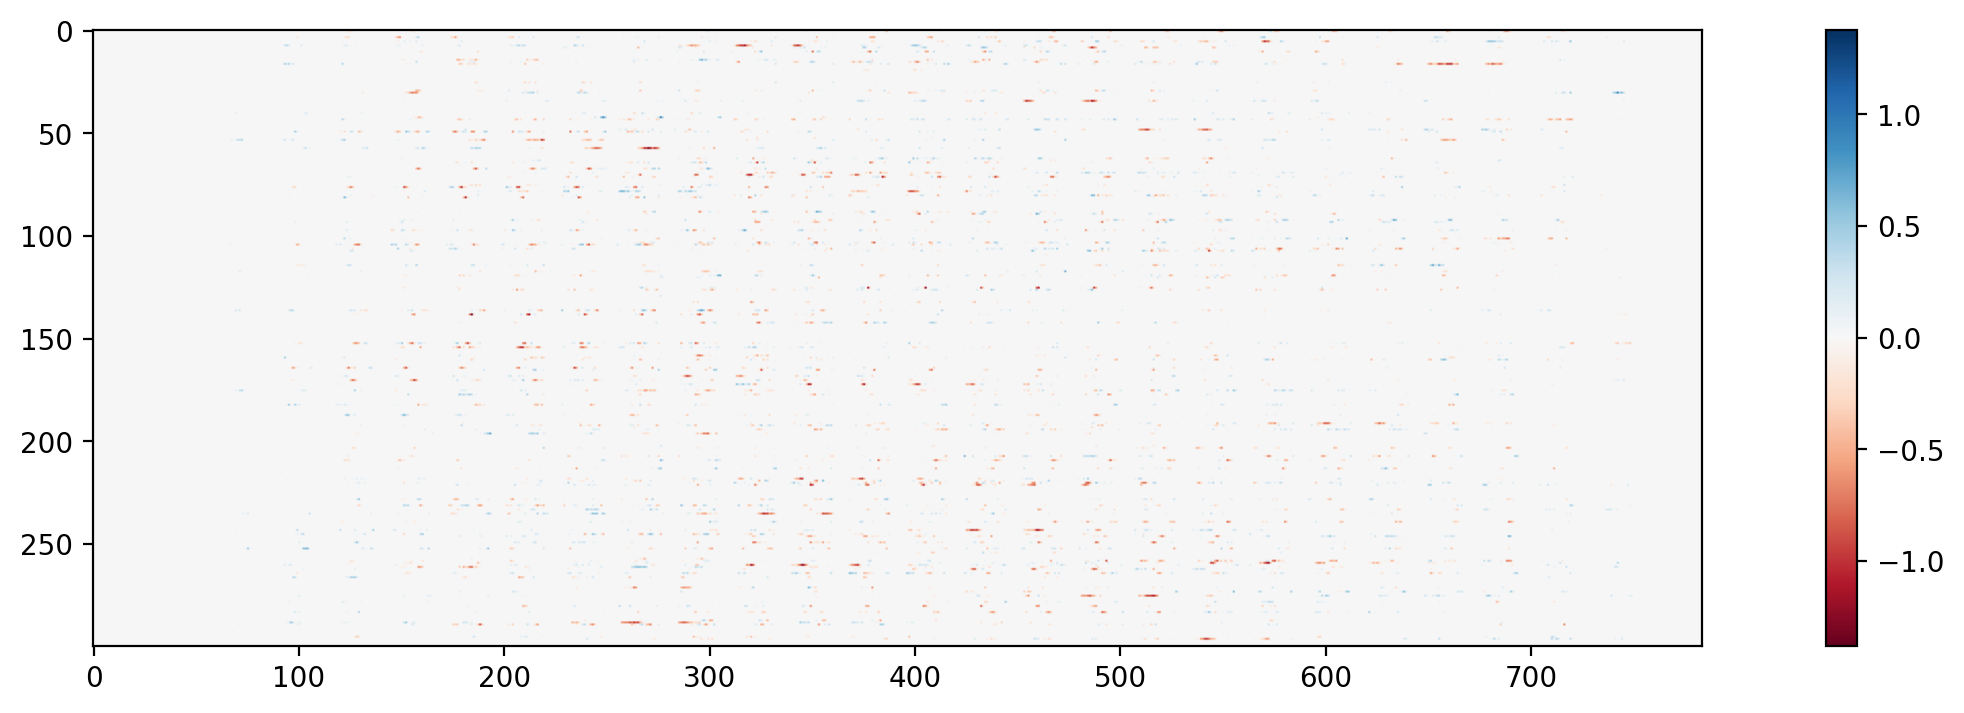

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl

from matplotlib import rcParams
rcParams['figure.figsize'] = 16, 4
rcParams['figure.dpi'] = 200


mask = (model.fc1.log_alpha.detach().cpu().numpy() < 3).astype(np.float32)
W = model.fc1.mu.detach().cpu().numpy()

# Normalize color map
max_val = np.max(np.abs(mask * W))
norm = mpl.colors.Normalize(vmin=-max_val,vmax=max_val)

plt.imshow(mask * W, cmap='RdBu', interpolation=None, norm=norm)
plt.colorbar()

(np.float64(-0.5), np.float64(419.5), np.float64(419.5), np.float64(-0.5))

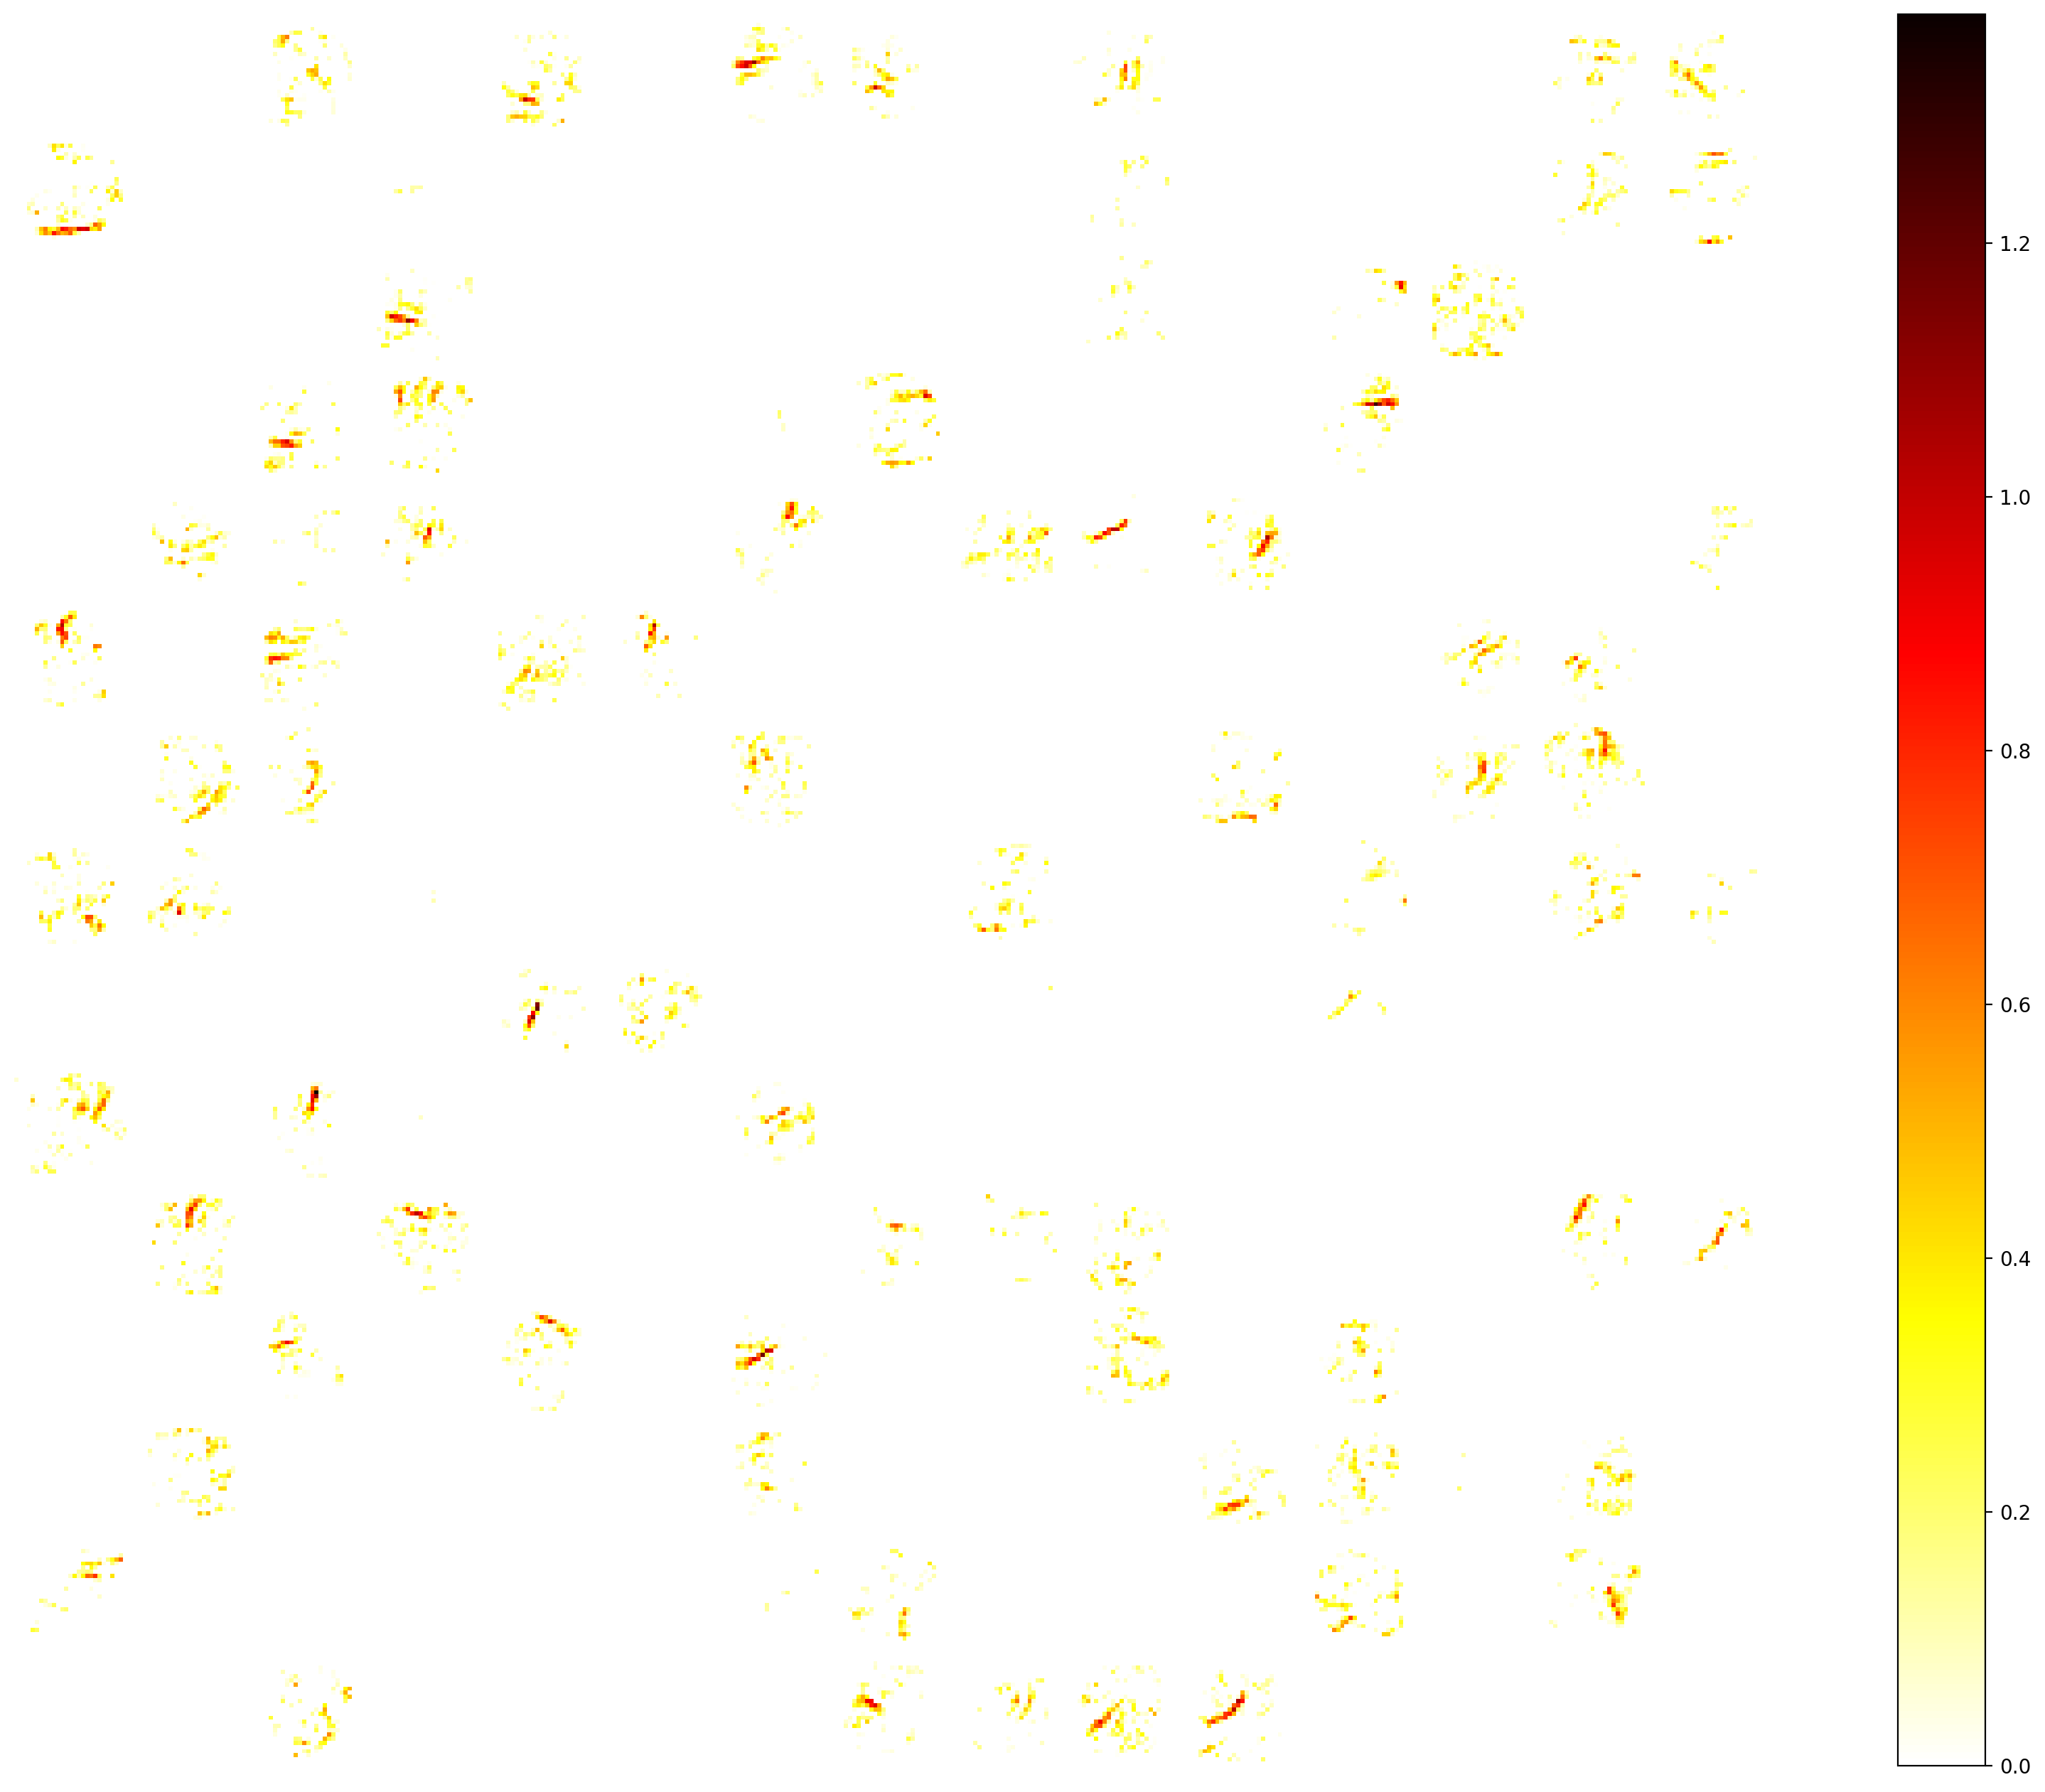

In [15]:
s = 0
z = np.zeros((28*15, 28*15))

for i in range(15):
    for j in range(15):
        s += 1
        z[i*28:(i+1)*28, j*28:(j+1)*28] = np.abs((mask * W)[s].reshape(28, 28))

plt.figure(figsize=(24, 16))
plt.imshow(z, cmap='hot_r')
plt.colorbar()
plt.axis('off')

# Optional Research Assignment (up to 2 additional points)

1. Study the model: 
    - How sparsity and accuracy depend on maximum of KL-multiplier (kl_weight)?
    - How sparsity and accuracy depend on the initialization?
    - Study the KL: what if we optimize w.r.t. $\lambda^2$ using Adam instead of substituting the optimal $\lambda^2$?
    - How does the behaviour of optimization change if you use another parameterization for the approximate posterior? How does it affect the variance of the stochastic gradients?
2. Compression:
    - What can we do to obtain better compression results with small quality degradation?
    - Propose and eval several options.
3. Study the Local reparametrization trick: 
    - Does it really accelerate convergence?
    - Does variance of gradient decrease?
    
You can do one out of three parts. You need to provide evidence for results e.g., plots, etc.